<a href="https://colab.research.google.com/github/swetha040206/DSV-ASSIGNEMNT-29-01/blob/main/Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


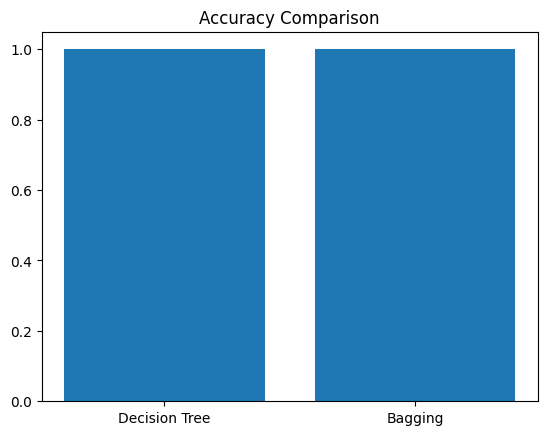

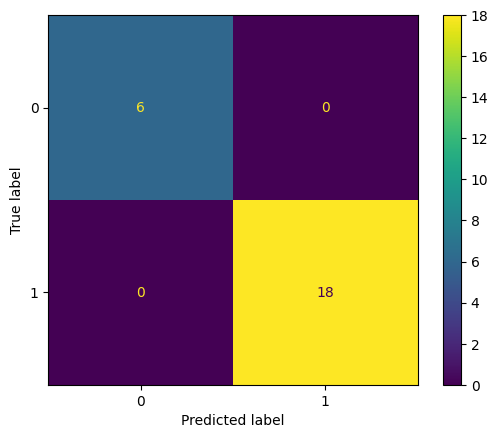

In [5]:
#LAB EXPERIMENT NO 6-IMPLEMENTATION OF ENSEMBLE TECHNIQUE
# Roll No:24BAD123
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Bar Graph
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(bag, X_test, y_test)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


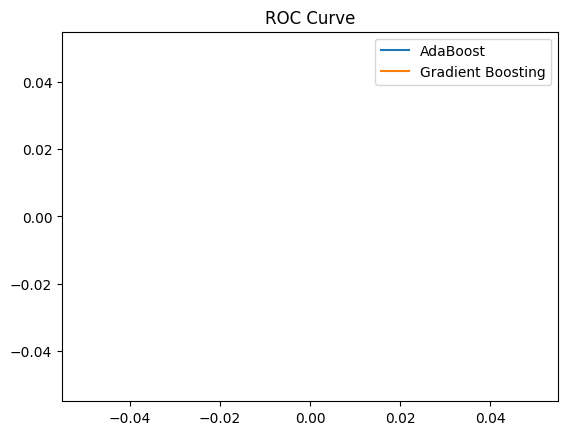

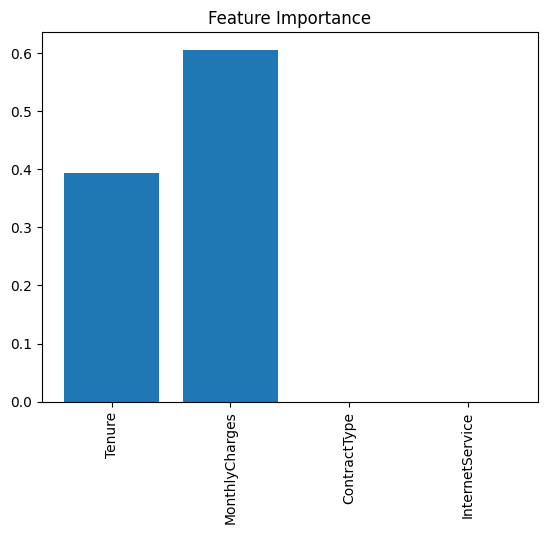

In [6]:
# Roll No:24BAD123

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

# Load dataset
df = pd.read_csv("churn_boosting.csv")

# Encode categorical
df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# ROC Curve
y_pred_ada = ada.predict_proba(X_test)[:,1]
y_pred_gb = gb.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, y_pred_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_gb)

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

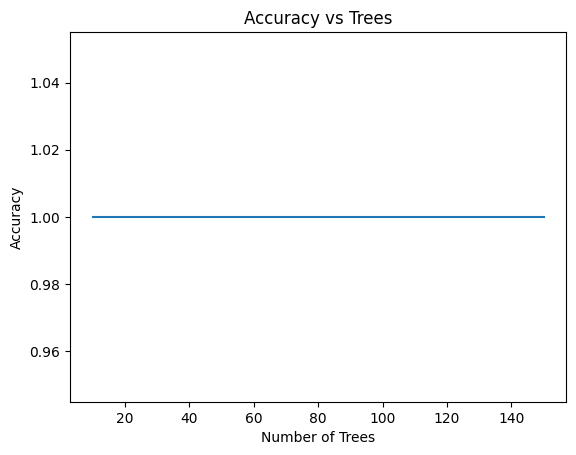

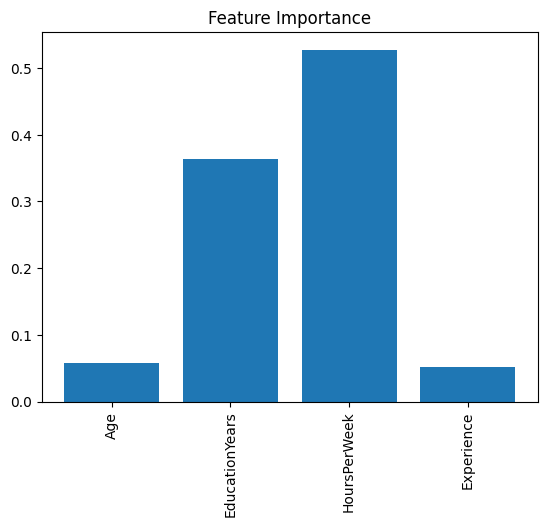

In [8]:
# Roll No:24BAD123

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("income_random_forest.csv")

df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

trees = [10, 50, 100, 150]
acc = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

# Graph
plt.plot(trees, acc)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Trees")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

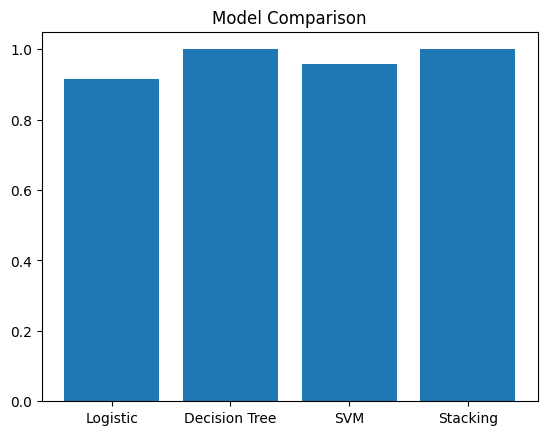

In [10]:
# Roll No:24BAD123

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("heart_stacking.csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base models
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

# Individual models
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

acc = []
names = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))
    names.append(name)

# Stacking accuracy
y_pred_stack = stack.predict(X_test)
acc.append(accuracy_score(y_test, y_pred_stack))
names.append("Stacking")

# Plot
plt.bar(names, acc)
plt.title("Model Comparison")
plt.show()

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64
After SMOTE:
 Fraud
0    110
1    110
Name: count, dtype: int64


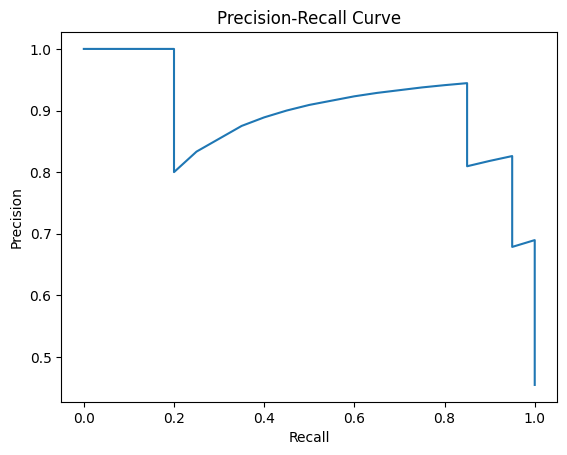

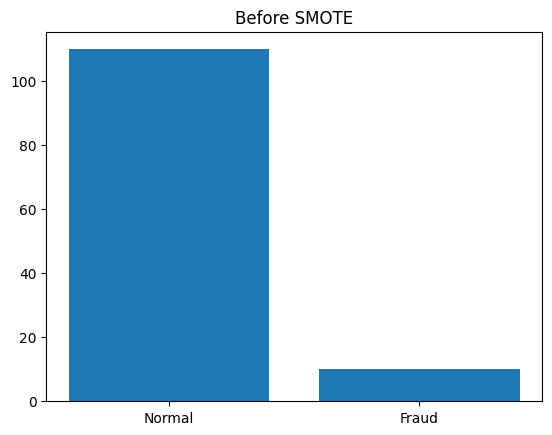

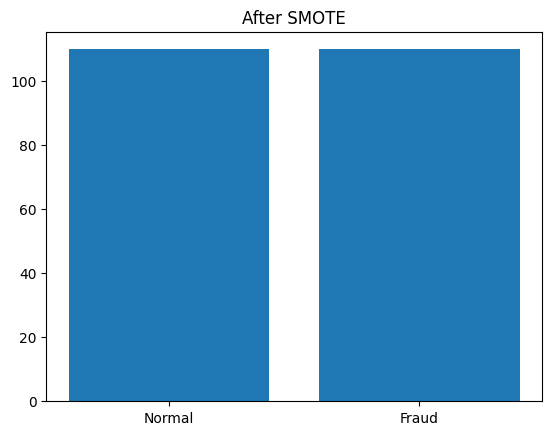

In [12]:
# Roll No: 24BAD123

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE

df = pd.read_csv("fraud_smote.csv")

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Before SMOTE
print("Before SMOTE:\n", y.value_counts())

# Apply SMOTE
sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:\n", y_res.value_counts())

# Train model
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Precision-Recall Curve
y_scores = model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Class distribution plot
plt.bar(["Normal", "Fraud"], y.value_counts())
plt.title("Before SMOTE")
plt.show()

plt.bar(["Normal", "Fraud"], y_res.value_counts())
plt.title("After SMOTE")
plt.show()